# Бутстреп (Bootstrap)

# Практика

- Подготовьте данные к классификации. Условно разделите вино на хорошее и плохое. Хорошим вином будем называть то, параметр quality которого — 6 и более.

- Разделите выборку на обучающую и тестовую в соотношении 70/30, в качестве значения параметра random_state возьмите число 42.

- Для начала обучите два классификатора: логистическую регрессию (с параметрами по умолчанию) и дерево решений (random_state = 42, максимальная глубина — 10).

1. Введите значение F1-score для классификатора, который показал наилучшее значение. Ответ округлите до трёх знаков после точки-разделителя.

2. Какой алгоритм показал наилучший результа (Логистическая регрессия или Решающее дерево).

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, mean_absolute_error, roc_auc_score, make_scorer
from sklearn.ensemble import BaggingClassifier, RandomForestRegressor, RandomForestClassifier

In [2]:
wine_data = pd.read_csv('Data/wineQualityReds.csv')
print(wine_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            1599 non-null   int64  
 1   fixed.acidity         1599 non-null   float64
 2   volatile.acidity      1599 non-null   float64
 3   citric.acid           1599 non-null   float64
 4   residual.sugar        1599 non-null   float64
 5   chlorides             1599 non-null   float64
 6   free.sulfur.dioxide   1599 non-null   float64
 7   total.sulfur.dioxide  1599 non-null   float64
 8   density               1599 non-null   float64
 9   pH                    1599 non-null   float64
 10  sulphates             1599 non-null   float64
 11  alcohol               1599 non-null   float64
 12  quality               1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB
None


Подготовим данные для классификации:

In [3]:
wine_data['good_or_bad'] = wine_data['quality'].apply(lambda x: 1 if x >= 6 else 0)
print(wine_data['good_or_bad'].value_counts())

good_or_bad
1    855
0    744
Name: count, dtype: int64


Разделим выборку на обучающую и тестовую:

In [4]:
X = wine_data.drop(['good_or_bad', 'quality'], axis=1)
y = wine_data['good_or_bad']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
    )

Обучим два классификатора:

In [5]:
# Логистическая регрессия
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
y_test_pred_lr = lr_model.predict(X_test)

# Дерево решений
dtc_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dtc_model.fit(X_train, y_train)
y_test_pred_dtc = dtc_model.predict(X_test)

# Расчёт F1-score
f1_lr = f1_score(y_test, y_test_pred_lr)
f1_dtc = f1_score(y_test, y_test_pred_dtc)

print(f'F1_score для логистической регресси: {f1_lr:.3f}')
print(f'F1_score для деревьев решений: {f1_dtc:.3f}')

F1_score для логистической регресси: 0.739
F1_score для деревьев решений: 0.760


/Users/alexander/.pyenv/versions/3.13.2/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Обучите модель с использованием бэггинга (класс BaggingClassifier с random_state=42).

Возьмите из предыдущего задания алгоритм, показавший наилучшее качество, и укажите для него новое количество моделей — 1500. Вычислите новое значение F1-score.

In [6]:
# Дерево решений
dtc_model = DecisionTreeClassifier(random_state=42, max_depth=10)

# Бэггинг
bagging_model = BaggingClassifier(
    estimator=dtc_model,
    n_estimators=1500,
    random_state=42)

# Обучаем модель Bagging
bagging_model.fit(X_train, y_train)

# Получаем прогнозы для тестовой выборки
y_test_pred = bagging_model.predict(X_test)

# Расчёт F1-score
f1_bagging = f1_score(y_test, y_test_pred)
print(f'F1_score для BaggingClassifier: {f1_bagging:.3f}')

F1_score для BaggingClassifier: 0.824


# Случайный лес (RandomForest)

# Практика

Мы будем анализировать набор данных Boston Houses, в котором объектами являются районы города, признаками — некие социальные и географические характеристики района, а целевой переменной — медианная стоимость домов в районе. Таким образом, мы будем решать задачу регрессии.

Описание признаков:

- crim_rate — уровень преступности в районе;
- zn — доля участков площадью более 25 000 кв. футов;
- business — уровень развитости бизнеса в районе;
- river — наличие реки в районе;
- nit_oxiden — концентрация оксидов азота в воздухе;
- rooms — среднее число комнат в домах района;
- age — процент домов, построенных до 1940 года;
- dist — расстояние до центров занятости;
- highways_index — индекс доступности крупных дорог;
- tax — средняя ставка налога на имущество;
- pup_per_teac — среднее число учеников на одного учителя;
- lower — процент малообеспеченного населения в районе;
- target — медианная стоимость домов в районе (целевая переменная).

1. Разбейте набор данных на обучающую и тестовую выборку в соотношении 70/30, при разбиении задайте параметр random_state = 13.

Какое получилось среднее значение медианных цен на обучающей выборке? Ответ округлите до двух знаков после точки-разделителя.

2. Обучите линейную регрессию с параметрами по умолчанию.

В качестве ответа введите ошибку MAE на тестовой выборке. Ответ округлите до двух знаков после точки-разделителя.

3. Обучите решающее дерево с параметрами по умолчанию и аргументом random_state = 13.

Можно ли, опираясь на результаты, сделать вывод, что алгоритм переобучился?

4. Обучите четыре случайных леса с числом деревьев 3, 10, 100, 500 и параметром random_state = 13.

В качестве ответа введите наименьшую полученную ошибку MAE на тестовой выборке. Ответ округлите до двух знаков после точки-разделителя.

In [7]:
boston_data = pd.read_csv('Data/boston_houses.csv')
print(boston_data.info())

# Заменим кириллическую 'с' на латинскую 'c' в названиях столбцов (ошибка в pup_per_teaс)
boston_data.columns = boston_data.columns.str.replace('с', 'c', regex=False)

# Список столбцов, которые нужно привести к числовому типу
columns_to_convert = [
    'crim_rate', 'zn', 'business', 'nit_oxiden', 'rooms',
    'age', 'dist', 'pup_per_teac', 'lower', 'target'
]

# Очищаем и преобразуем каждый столбец
for col in columns_to_convert:
    boston_data[col] = (
        boston_data[col]
        .astype(str)  # Приводим к строкам
        .str.replace(',', '.', regex=False)  # Заменяем запятые на точки
        .str.strip()  # Удаляем пробелы
    )
    boston_data[col] = pd.to_numeric(boston_data[col], errors='coerce')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   crim_rate       506 non-null    object
 1   zn              506 non-null    object
 2   business        506 non-null    object
 3   river           506 non-null    int64 
 4   nit_oxiden      506 non-null    object
 5   rooms           506 non-null    object
 6   age             506 non-null    object
 7   dist            506 non-null    object
 8   highways_index  506 non-null    int64 
 9   tax             506 non-null    int64 
 10  pup_per_teaс    506 non-null    object
 11  lower           506 non-null    object
 12  target          506 non-null    object
dtypes: int64(3), object(10)
memory usage: 51.5+ KB
None


Разобьем набор данных на обучающую и тестовую выборку:

In [8]:
X = boston_data[boston_data.columns[:-1]]
y = boston_data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=13
    )

target_mean_prices = round(y_train.mean(), 2)
print(target_mean_prices)

22.77


Линейная регрессия с параметрами по умолчанию:

In [9]:
# Линейная регрессия
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_test_pred_lr = lr_model.predict(X_test)

# Расчёт MAE
mae = mean_absolute_error(y_test, y_test_pred_lr)
print(f'MAE для Линейной регрессии: {mae:.2f}')

MAE для Линейной регрессии: 3.72


Дерево решений с параметрами по умолчанию:

In [10]:
# Дерево решений
dtc_model = DecisionTreeRegressor(random_state=13)
dtc_model.fit(X_train, y_train)
y_test_pred_dtc = dtc_model.predict(X_test)

# Расчёт MAE
mae = mean_absolute_error(y_test, y_test_pred_dtc)
print(f'MAE для Дерева решений: {mae:.2f}')

MAE для Дерева решений: 2.84


Обучим четыре случайных леса:

In [11]:
mae_scores = []
tree_counts = [3, 10, 100, 500]

for n in tree_counts:
    model = RandomForestRegressor(n_estimators=n, random_state=13)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mae_scores.append((n, mae))

# Выводим все MAE
for n, mae in mae_scores:
    print(f'{n} деревьев: MAE = {mae:.2f}')
    
# Минимальное MAE
best_mae = min(mae_scores, key=lambda x: x[1])[1]
print(f'\nМинимальное MAE: {best_mae:.2f}')

3 деревьев: MAE = 2.93
10 деревьев: MAE = 2.47
100 деревьев: MAE = 2.26
500 деревьев: MAE = 2.24

Минимальное MAE: 2.24


# Практика (Случайный лес)

Задача, тут предстоит предсказывать будет ли дождь в Австралии.

In [12]:
rain_data = pd.read_csv('Data/weatherAUS.csv')
rain_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

- Date — дата, в которую зафиксировано наблюдение;
- Location — местонахождение метеорологической станции;
- MinTemp — минимальная температура (℃);
- MaxTemp — максимальная температура (℃);
- Rainfall — количество осадков (дождь) за сутки (мм);
- Evaporation — количество испарений до 9 утра (мм);
- Sunshine — количество часов в сутках, когда светило солнце;
- WindGustDir — направление самого сильного порыва ветра за последние 24 часа;
- WindGustSpeed — скорость самого сильного порыва ветра за последние 24 часа;
- WindDir9am — направление ветра в 9 утра;
- WindDir3pm — направление ветра в 3 часа дня;
- WindSpeed9am — скорость ветра в 9 часов утра;
- WindSpeed3pm — скорость ветра в 3 часа дня;
- Humidity9am — влажность в 9 утра;
- Humidity3pm — влажность в 3 часа дня;
- Pressure9am — атмосферное давление в 9 утра;
- Pressure3pm — атмосферное давление в 3 часа дня;
- Cloud9am — часть неба, закрытая облаками, в 9 утра;
- Cloud3pm — часть неба, закрытая облаками, в 3 часа дня;
- Temp9am — температура в 9 утра;
- Temp3pm — температура в 3 часа дня;
- RainToday — наличие дождя в этот день;

- RainTomorrow — наличие дождя на следующий день.

Данные содержат 23 признака и 145 460 наблюдений. Из этих 23 признаков шесть — категориальные, в одном записана дата, а остальные являются непрерывными числовыми данными.

Примеры числовых признаков: температура, скорость ветра, влажность, облачность, атмосферное давление в разное время суток, количество осадков, испарение, количество часов с солнечной погодой.
Примеры категориальных признаков: местоположение, направление ветра в разное время суток, наличие дождя сегодня или завтра.

Целевой переменной является столбец __RainTomorrow.__ Значение этой переменной мы и будем пытаться предсказать.

In [13]:
# Пропуски в данных
print(f'Количество пропусков в данных: {rain_data.isnull().sum().sum()}')

# Распределение целевой переменной
print(rain_data['RainTomorrow'].value_counts())

# Считает дубликаты
mask = rain_data.duplicated()
duplicates = rain_data[mask]
display(f'Число найденных полных дубликатов (до удаления): {duplicates.shape[0]}')

Количество пропусков в данных: 343248
RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64


'Число найденных полных дубликатов (до удаления): 0'

In [14]:
# Число пропусков в столбцах
null_data = rain_data.isnull().sum()
print(f'Число пропусков: {null_data[null_data > 0]}')

rain_data.drop(['Evaporation', 'Sunshine', 'Cloud3pm'], axis=1, inplace=True)

Число пропусков: MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64


In [15]:
rain_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   WindGustDir    135134 non-null  object 
 6   WindGustSpeed  135197 non-null  float64
 7   WindDir9am     134894 non-null  object 
 8   WindDir3pm     141232 non-null  object 
 9   WindSpeed9am   143693 non-null  float64
 10  WindSpeed3pm   142398 non-null  float64
 11  Humidity9am    142806 non-null  float64
 12  Humidity3pm    140953 non-null  float64
 13  Pressure9am    130395 non-null  float64
 14  Pressure3pm    130432 non-null  float64
 15  Cloud9am       89572 non-null   float64
 16  Temp9am        143693 non-null  float64
 17  Temp3pm        141851 non-nul

In [16]:
# Обработаем категориальные признаки
rain_data.RainToday = rain_data.RainToday.map({'No': 0, 'Yes': 1})
rain_data.RainTomorrow = rain_data.RainTomorrow.map({'No': 0, 'Yes': 1})

Вычислите среднее арифметическое для преобразованного признака RainToday и запишите его в ответ, предварительно округлив до двух знаков после точки-разделителя.

In [17]:
print(round(rain_data['RainToday'].mean(), 2))

0.22


Обработайте признак Date таким образом, чтобы выделить в отдельный признак Month (номер месяца). Изначальный признак Date удалите. Определите, какой месяц имеет самую большую часть дождливых дней относительно всех дней месяца. В качестве ответа введите порядковый номер месяца.

In [18]:
rain_data['Date'] = pd.to_datetime(rain_data['Date'])
# Создаем новый признак - месяц
rain_data['Month'] = rain_data['Date'].dt.month
rain_data.drop(['Date'], axis=1, inplace = True)

In [19]:
df_season = rain_data.groupby('Month').mean(numeric_only=True)
df_season[['RainToday']]

,RainToday
Month,
1,0.189484
2,0.206746
3,0.217135
4,0.216845
5,0.222163
6,0.263638
7,0.270736
8,0.253167
9,0.229135


In [20]:
# Обработаем остальные категориальные признаки
categoricals = ['Month', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
# Применяем get_dummies для кодирования категориальных признаков
rain_data_encoded = pd.get_dummies(data=rain_data, columns=categoricals)
# Считаем количество признаков после кодирования
print(rain_data_encoded.shape)

(145460, 124)


In [21]:
rain_data_encoded.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am',
       'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
       'Pressure3pm',
       ...
       'WindDir3pm_NNW', 'WindDir3pm_NW', 'WindDir3pm_S', 'WindDir3pm_SE',
       'WindDir3pm_SSE', 'WindDir3pm_SSW', 'WindDir3pm_SW', 'WindDir3pm_W',
       'WindDir3pm_WNW', 'WindDir3pm_WSW'],
      dtype='object', length=124)

Осталось совсем немного. Удалите все строки, где есть пропуски. Далее разбейте данные на обучающую и тестовую выборки в соотношении 70/30, в качестве значения параметра random_state возьмите число 31.

Каково среднее значение целевой переменной на тестовой выборке? Ответ округлите до двух знаков после точки-разделителя.

In [22]:
rain_data_encoded.dropna(inplace=True)

X = rain_data_encoded.drop('RainTomorrow', axis=1)
y = rain_data_encoded['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=31
    )

target_mean = round(y_test.mean(), 2)
print(target_mean)

0.23


Теперь давайте вспомним про бутстреп. Он не понадобится нам для решения этой задачи, но будет полезно реализовать его «вручную».

Сделайте оценку стандартного отклонения для среднего значения минимальной температуры для обучающей выборки (то есть для среднего значения по признаку MinTemp). Для этого сгенерируйте 1000 случайных выборок из наших данных — каждая из них должна быть такого же объёма, как и обучающая выборка. Для генерации выборки используйте np.random.randint(): сгенерируйте необходимое количество индексов и по ним извлеките соответствующие элементы выборки. Случайность фиксируйте с помощью np.random.seed(31).

Для каждой выборки вычислите среднее значение, а после найдите стандартное отклонение для этих значений. Ответ округлите до двух знаков после точки-разделителя.

In [23]:
def bootstrap(data, n_iter):
    index = np.random.randint(0, len(data), (n_iter, len(data)))
    sample = data[index] # выбираем значения по индексам
    return sample

target = X_train['MinTemp'].values #выбираем целевую переменную
np.random.seed(31)
mean_values = [np.mean(x) for x in bootstrap(target, 1000)]
print(round(np.std(mean_values), 2))

0.03


Теперь можно перейти к обучению прогностических моделей. Начнём с того, что построим простейшую логистическую регрессию (без настройки гиперпараметров). Это будет та модель, с качеством которой мы будем сравнивать результаты, полученные далее.

В качестве ответа введите значение метрики roc_auc на тестовой выборке. Ответ округлите до двух знаков после точки-разделителя.

In [24]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)

y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

auc_roc = roc_auc_score(y_test, y_pred_test)
print(f'Метрика AUC ROC: {auc_roc:.2f}')

Метрика AUC ROC: 0.73


/Users/alexander/.pyenv/versions/3.13.2/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Теперь попробуйте обучить на наших данных другой алгоритм — дерево решений. С помощью GridSearchCV сделайте перебор гиперпараметров по следующей сетке:

Для параметра кросс-валидации cv задайте значение 3. Для решающего дерева определите параметр random_state=42. Остальные параметры оставьте по умолчанию.

1. Вычислите значение roc_auc для решающего дерева с гиперпараметрами, определёнными в качестве оптимальных. Ответ округлите до двух знаков после точки-разделителя.

2. Какие значения гиперпараметров были выбраны как оптимальные?

In [25]:
# Инициализация Дерева решений для задачи регрессии
complement_model = DecisionTreeClassifier(random_state=42)

params = {'max_leaf_nodes': list(range(2, 10)), 'min_samples_split': [2, 3, 4], 'max_depth': [5,7,9,11]}

# Инициализация поиска по сетке с использованием кросс-валидации (cv=3) и метрики точности (roc_auc)
grid_search = GridSearchCV(
    estimator=complement_model,  # классификатор
    param_grid=params,       # сетка параметров для подбора
    cv=3,                    # количество фолдов для кросс-валидации
    scoring=make_scorer(roc_auc_score)  # метрика, используемая для оценки модели
)

# Обучение модели на обучающей выборке с кросс-валидацией для подбора оптимального параметра 'alpha'
grid_search.fit(X_train, y_train)

# Лучший параметр соответствующий результат
print(f"Лучший параметр max_depth: {grid_search.best_params_['max_depth']}")
print(f"Лучший параметр max_leaf_nodes: {grid_search.best_params_['max_leaf_nodes']}")
print(f"Лучший параметр min_samples_split: {grid_search.best_params_['min_samples_split']}")
print(f"Лучший результат (roc_auc): {grid_search.best_score_:.2f}")
print()

# Прогнозирование на тестовой выборке с оптимальным параметром alpha
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Оценка качества модели на тестовой выборке
print(f"Roc-auc на тестовой выборке: {roc_auc_score(y_test, y_pred):.2f}")

Лучший параметр max_depth: 5
Лучший параметр max_leaf_nodes: 9
Лучший параметр min_samples_split: 2
Лучший результат (roc_auc): 0.71

Roc-auc на тестовой выборке: 0.70


К сожалению, деревья решений не помогли нам в улучшении качества модели, так что попробуем ещё уменьшить ошибку с помощью ансамблей.

Теперь постройте случайный лес, включающий 100 деревьев. Задайте параметр random_state=31. Остальные параметры оставьте по умолчанию.

Какой теперь будет метрика roc_auc на тестовой выборке? Ответ округлите до двух знаков после точки-разделителя.

In [26]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
auc_roc = roc_auc_score(y_test, y_pred)
print(f'Метрика AUC ROC: {auc_roc:.2f}')

Метрика AUC ROC: 0.73


Основные параметры, которые отвечают за качество обучения в случайном лесе, следующие:'max_features', 'min_samples_leaf', 'max_depth'.

Возьмите случайный лес из 100 деревьев и найдите оптимальную комбинацию этих трёх параметров. Сетка для перебора следующая:

Перебор осуществите с помощью GridSearchCV. Для параметра кросс-валидации cv задайте значение 3. Случайности фиксируйте параметром random_state = 31. Остальные значения оставьте по умолчанию.

Какое значение roc_auc получилось для оптимальных гиперпараметров?

In [27]:
# Инициализация Дерева решений для задачи регрессии
complement_model = RandomForestClassifier(n_estimators=100, random_state=31)

params = {'max_features': [ 4, 5, 6, 7], 'min_samples_leaf': [3, 5, 7, 9, 11], 'max_depth': [5, 10, 15]}

# Инициализация поиска по сетке с использованием кросс-валидации (cv=3) и метрики точности (roc_auc)
grid_search = GridSearchCV(
    estimator=complement_model,  # классификатор
    param_grid=params,       # сетка параметров для подбора
    cv=3,                    # количество фолдов для кросс-валидации
    scoring='roc_auc' # метрика, используемая для оценки моде
)

# Обучение модели на обучающей выборке с кросс-валидацией для подбора оптимального параметра 'alpha'
grid_search.fit(X_train, y_train)

# Лучший параметр соответствующий результат
print(f"Лучший результат (roc_auc): {grid_search.best_score_:.2f}")

Лучший результат (roc_auc): 0.87


In [28]:
best_model = grid_search.best_estimator_
y_pred_proba = best_model.predict_proba(X_test)[:,1]

# Получение важности признаков
feature_importances = best_model.feature_importances_

# Преобразуем в DataFrame для удобства
features_df = pd.DataFrame({
    'Feature': X_train.columns, # Используем имена признаков из обучающей выборки
    'Importance': feature_importances
})

# Сортировка по убыванию важности
features_df = features_df.sort_values(by='Importance', ascending=False)

# Выводим наиболее важные признаки
print(features_df)

                 Feature  Importance
7            Humidity3pm    0.250783
2               Rainfall    0.079757
6            Humidity9am    0.070403
10              Cloud9am    0.067092
9            Pressure3pm    0.065272
..                   ...         ...
50    Location_Newcastle    0.000000
66  Location_Tuggeranong    0.000000
62   Location_SalmonGums    0.000000
69      Location_Walpole    0.000000
72  Location_Witchcliffe    0.000000

[123 rows x 2 columns]


#  Бустинг

Данные, содержат результаты опроса клиентов авиакомпании по поводу их удовлетворённости полётом.

Нашей задачей будет предсказать удовлетворённость пассажиров.

Данные включают в себя следующие признаки:
- Gender — пол пассажира (женский, мужской);
- Customer Type — тип клиента (постоянный/непостоянный клиент);
- Age — возраст клиента;
- Type of Travel — цель перелета (личная/деловая поездка);
- Class — туристический класс пассажира (Business, Eco, Eco Plus);
- Flight distance — расстояние полета;
- Inflight wifi service — уровень удовлетворённости Wi-Fi (0 — не применимо, 1–5);
- Departure/Arrival time convenient — уровень удовлетворённости временем отправления и прибытия;
- Ease of Online booking — уровень удовлетворённости онлайн-бронированием;
- Gate location — уровень удовлетворённости расположением выхода на посадку;
- Food and drink — уровень удовлетворённости едой и напитками;
- Online boarding — уровень удовлетворённости онлайн-регистрацией;
- Seat comfort — уровень удовлетворённости комфортом сидений;
- Inflight entertainment — уровень удовлетворённости развлечениями на борту;
- On-board service — уровень удовлетворённости сервисом на борту;
- Leg room service — уровень удовлетворённости местом для ног;
- Baggage handling — уровень удовлетворённости обработкой багажа;
- Check-in service — уровень удовлетворённости услугами регистрации;
- Inflight service — уровень удовлетворённости обслуживанием во время полёта;
- Cleanliness — уровень удовлетворённости чистотой;
- Departure Delay in Minutes — задержка при отправлении (в минутах);
- Arrival Delay in Minutes — задержка при прибытии (в минутах);

- Satisfaction — удовлетворённость авиакомпанией — целевая переменная (satisfaction/neutral/dissatisfaction).

Библиотеки:

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_confusion_matrix

Загрузки и первичный осмотр:

In [30]:
air_data = pd.read_csv('Data/AirPass.csv', index_col=0)
print(air_data.info())
print()
print(f'Количество пропусков: {air_data.isnull().sum().sum()}')
print()
print(f'Количество уникальный значений: {air_data.nunique()}')
print()
print(f'Распределение целевой переменной: {air_data['satisfaction'].value_counts()}')

<class 'pandas.core.frame.DataFrame'>
Index: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  object 
 2   Customer Type                      103904 non-null  object 
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  object 
 5   Class                              103904 non-null  object 
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     103904 no

Теперь давайте избавимся от найденных пропусков. Заполните их все медианными значениями. После этого вычислите среднее арифметическое для признака, отражающего задержку при прибытии в минутах. Ответ округлите до двух знаков после точки-разделителя.

In [31]:
# Заполняем только числовые столбцы медианой, не удаляя остальны
num_cols = air_data.select_dtypes(include='number').columns
air_data[num_cols] = air_data[num_cols].fillna(air_data[num_cols].median(numeric_only=True))

In [32]:
delay_in_min_mean = round(air_data['Arrival Delay in Minutes'].mean(), 2)
print(f'Среднее арифметическое для признака - задержка при прибытии в минутах: {delay_in_min_mean}')

Среднее арифметическое для признака - задержка при прибытии в минутах: 15.13


Проведём небольшой разведывательный анализ. Посмотрим, в каких категориях пассажиров превалировали удовлетворённые полетом клиенты.

1. Сравните удовлетворённость полётом мужчин и женщин.

,Gender,satisfaction,count,fraction
0,Female,neutral or dissatisfied,30193,0.572629
1,Female,satisfied,22534,0.427371
2,Male,neutral or dissatisfied,28686,0.560525
3,Male,satisfied,22491,0.439475


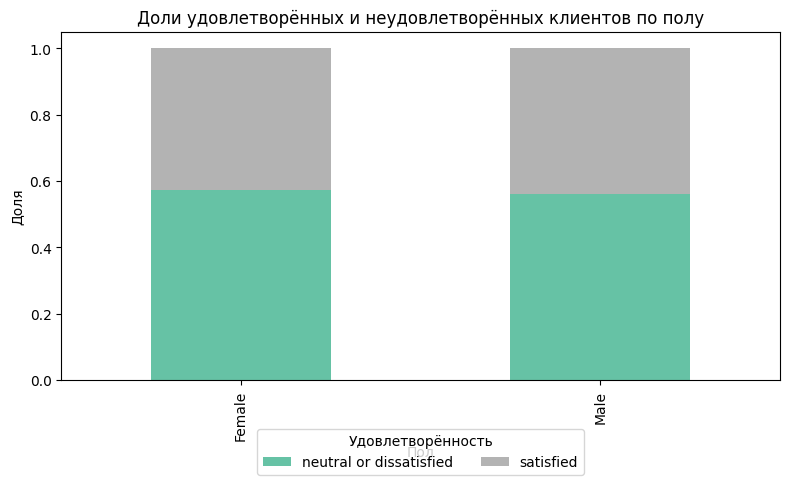

In [33]:
# категория - пол
# Считаем количество для каждой категории
gender_satisfactions = (
    air_data.groupby('Gender')['satisfaction']
    .value_counts()
    .rename('count')
    .reset_index()
)

# Считаем долю в пределах каждого пола
gender_satisfactions['fraction'] = gender_satisfactions.groupby('Gender')['count'].transform(lambda x: x / x.sum())
display(gender_satisfactions)

# Переходим к удобному формату для stacked bar chart
pivot_df = gender_satisfactions.pivot(index='Gender', columns='satisfaction', values='fraction')

# Строим stacked bar chart
pivot_df.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Set2')

plt.title('Доли удовлетворённых и неудовлетворённых клиентов по полу')
plt.ylabel('Доля')
plt.xlabel('Пол')
plt.legend(title='Удовлетворённость', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
plt.tight_layout()
plt.show()

### Вывод:

В обеих категориях больше нейтрально настроенных/недовольных.

2. Теперь сравним категории пассажиров в зависимости от их цели поездки.

,Type of Travel,satisfaction,count,fraction
0,Business travel,satisfied,41746,0.582597
1,Business travel,neutral or dissatisfied,29909,0.417403
2,Personal Travel,neutral or dissatisfied,28970,0.898322
3,Personal Travel,satisfied,3279,0.101678


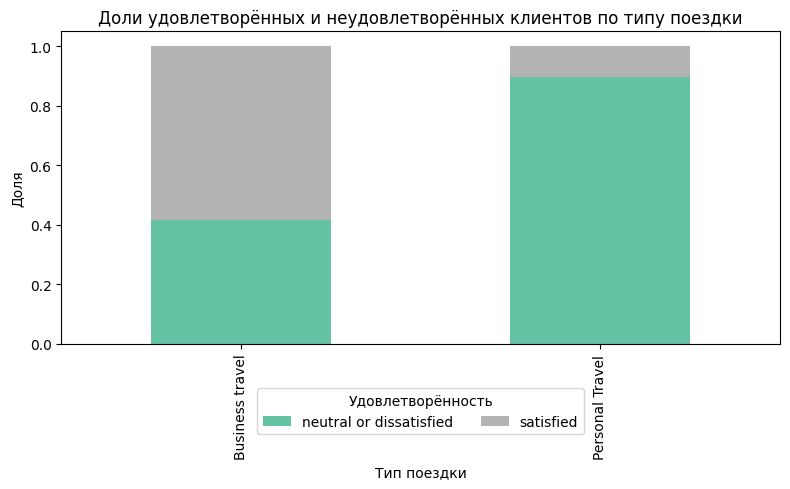

In [34]:
# категория - цель поездки
type_of_travel_satisfaction = (
    air_data.groupby('Type of Travel')['satisfaction']
    .value_counts()
    .rename('count')
    .reset_index()
)

# Считаем долю в пределах каждой цели поездки
type_of_travel_satisfaction['fraction'] = type_of_travel_satisfaction.groupby('Type of Travel')['count'].transform(lambda x: x / x.sum())
display(type_of_travel_satisfaction)

# Переходим к удобному формату для stacked bar chart
pivot_df = type_of_travel_satisfaction.pivot(index='Type of Travel', columns='satisfaction', values='fraction')

# Строим stacked bar chart
pivot_df.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Set2')

plt.title('Доли удовлетворённых и неудовлетворённых клиентов по типу поездки')
plt.ylabel('Доля')
plt.xlabel('Тип поездки')
plt.legend(title='Удовлетворённость', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
plt.tight_layout()
plt.show()

### Вывод:

Среди тех, кто летал в деловую поездку, довольных больше, чем нейтрально настроенных/недовольных.

Среди тех, кто летал по личным делам, довольных меньше, чем нейтрально настроенных/недовольных.

3. В каком туристическом классе наибольший процент довольных клиентов?

,Class,satisfaction,count,fraction
0,Business,satisfied,34480,0.694251
1,Business,neutral or dissatisfied,15185,0.305749
2,Eco,neutral or dissatisfied,38044,0.813862
3,Eco,satisfied,8701,0.186138
4,Eco Plus,neutral or dissatisfied,5650,0.753936
5,Eco Plus,satisfied,1844,0.246064


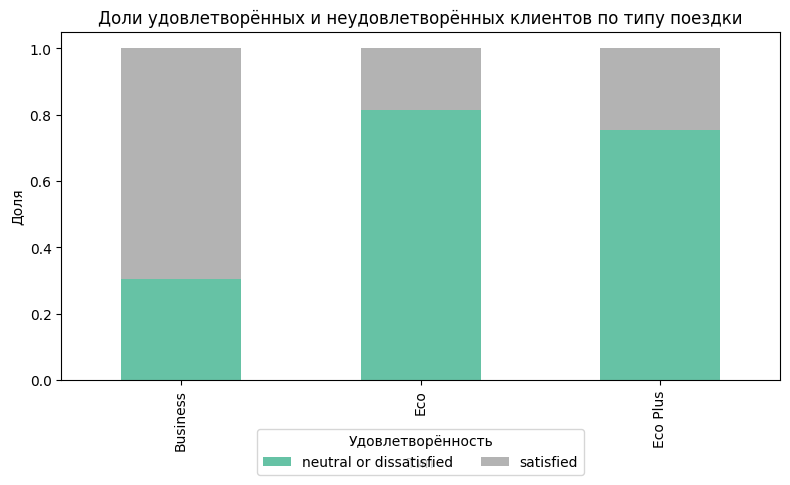

In [35]:
# категория - тип поездки

# Считаем количество для каждого типа поездки
class_satisfactions = (
    air_data.groupby('Class')['satisfaction']
    .value_counts()
    .rename('count')
    .reset_index()
)

# Считаем долю в пределах каждого типа
class_satisfactions['fraction'] = class_satisfactions.groupby('Class')['count'].transform(lambda x: x / x.sum())
display(class_satisfactions)

# Переходим к удобному формату для stacked bar chart
pivot_df = class_satisfactions.pivot(index='Class', columns='satisfaction', values='fraction')

# Строим stacked bar chart
pivot_df.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Set2')

plt.title('Доли удовлетворённых и неудовлетворённых клиентов по типу поездки')
plt.ylabel('Доля')
plt.xlabel('Тип')
plt.legend(title='Удовлетворённость', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
plt.tight_layout()
plt.show()

### Вывод:

Business

Перекодируем часть бинарных признаков, чтобы использовать их при обучении:

In [36]:
# Преобразуем целевой признак 'satisfaction' в числовой формат:
# 'neutral or dissatisfied' → 0, 'satisfied' → 1
air_data['satisfaction'] = air_data['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

# Кодируем тип клиента: 'Loyal Customer' → 1, 'disloyal Customer' → 0
# Это может отразить лояльность как положительный фактор
air_data['Customer Type'] = air_data['Customer Type'].map({'Loyal Customer': 1, 'disloyal Customer': 0})

# Кодируем тип путешествия: 'Personal Travel' → 0, 'Business travel' → 1
# Можно предположить, что деловые поездки более критичны к качеству сервиса
air_data['Type of Travel'] = air_data['Type of Travel'].map({'Personal Travel': 0, 'Business travel': 1})

# Кодируем пол: 'Male' → 0, 'Female' → 1
# Просто бинарное кодирование без привязки к значению
air_data['Gender'] = air_data['Gender'].map({'Male': 0, 'Female': 1})

Для остальных категориальных признаков создайте dummy-переменные. Сделайте это с помощью функции get_dummies() из библиотеки Pandas, параметры не меняйте. Сколько теперь признаков в данных (включая целевую переменную)?

In [37]:
# Применяем get_dummies для кодирования категориальных признаков
air_data_encoded = pd.get_dummies(data=air_data)
# Считаем количество признаков после кодирования
print(air_data_encoded.shape)

(103904, 26)


Теперь практически добрались до обучения модели. Разбейте данные на обучающую и тестовую выборки в соотношении 80/20, параметр random_state = 26. Сколько наблюдений попало в тестовую выборку?

In [38]:
X = air_data_encoded.drop(['satisfaction'], axis=1)
y = air_data_encoded['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=26
    )

print(X_test.shape[0])

20781


Теперь нам необходимо реализовать масштабирование данных. Для этого обучите на обучающей выборке метод StandardScaler() и с помощью него преобразуйте и обучающую, и тестовую выборки. Не забудьте, что целевую переменную обрабатывать не нужно.

In [39]:
# Инициализируем StandardScaler
scaler = StandardScaler()

# Обучаем scaler только на тренировочных данных и сразу трансформируем их
X_train_scaled = scaler.fit_transform(X_train)
# Применяем ТОЛЬКО transform к тестовым данным (fit НЕ вызываем!)
X_test_scaled = scaler.transform(X_test)

# Получение первого значения матрицы тестов
first_value = round(X_test_scaled[0, 0], 2)
print(first_value)

0.94


Перейдём к обучению моделей. В качестве первой модели возьмём самую простую — логистическую регрессию. Мы делаем это для того, чтобы потом сравнивать с ней полученные результаты: так вы сможете выяснить, насколько ансамбли смогут улучшить точность прогноза.

Обучите логистическую регрессию с параметрами по умолчанию на наших данных. В качестве ответа введите значение метрики f1_score. Ответ округлите до трёх знаков после точки-разделителя.

In [40]:
# Импортируем логистическую регрессию
lr_model = LogisticRegression()  # создаём экземпляр модели логистической регрессии с параметрами по умолчанию

# Обучаем модель на тренировочных данных
lr_model.fit(X_train_scaled, y_train)  # обучаем модель, используя признаки X_train и целевую переменную y_train

# Предсказываем метки классов на тестовой выборке
y_pred = lr_model.predict(X_test_scaled)  # модель делает предсказания классов на тестовой выборке

# Вычисляем метрику F1 (сбалансированная метрика между precision и recall)
f1 = f1_score(y_test, y_pred)  # сравниваем предсказания с реальными метками и рассчитываем F1-метрику

# Выводим значение F1 score с округлением до 3 знаков после запятой
print(f'F1 score: {f1:.3f}')  # выводим результат на экран

F1 score: 0.855


Теперь перейдём к бустингу. Начнём с обучения первой модели — AdaBoost. В качестве базовой модели для неё возьмите решающее дерево с параметром random_state = 26.

Обучите AdaBoost, зафиксировав random_state со значением 26 и задав темп обучения 0.01. В качестве ответа введите значение метрики f1_score. Ответ округлите до трёх знаков после точки-разделителя.

In [41]:
# Базовая модель — дерево решений с random_state=26
base_model = DecisionTreeClassifier(random_state=26)

# Создаём модель AdaBoost с параметрами по умолчанию
ada_model = AdaBoostClassifier(
    estimator=base_model,
    learning_rate=0.01,
    random_state=26
    )

# Обучаем модель
ada_model.fit(X_train_scaled, y_train)

# Делаем предсказания
y_pred = ada_model.predict(X_test_scaled)

# Вычисляем метрику F1
f1 = f1_score(y_test, y_pred)
print(f'F1 score (AdaBoost): {f1:.3f}')

F1 score (AdaBoost): 0.940


Перейдем к следующему алгоритму — градиентному бустингу.

Будем настраивать количество деревьев и темп обучения, делая перебор по следующей сетке:

Используйте для поиска оптимальных параметров GridSearchCV, а для ускорения работы алгоритма задайте параметр кросс-валидации, равный 3.

Какое наибольшее значение метрики f1_score получилось? Ответ округлите до трёх знаков после точки-разделителя.

In [44]:
params = {"n_estimators":2**np.arange(8), "learning_rate":0.1**np.arange(3)}

# Инициализация Дерева решений для задачи регрессии
gb_model = GradientBoostingClassifier(random_state=26)

# Инициализация поиска по сетке с использованием кросс-валидации
grid_search = GridSearchCV(
    estimator=gb_model,  # классификатор
    param_grid=params,       # сетка параметров для подбора
    cv=3,                    # количество фолдов для кросс-валидации
    scoring='f1' # метрика, используемая для оценки моде
)

# Обучение модели на обучающей выборке с кросс-валидацией
grid_search.fit(X_train_scaled, y_train)

# Лучший параметр соответствующий результат
print(f"Лучший результат (f1): {grid_search.best_score_:.3f}")

Лучший результат (f1): 0.949


Обучите алгоритм XGBoost. Так как он достаточно мощный «из коробки», определите его с параметрами по умолчанию, только задайте random_state = 26. Какое значение метрики f1_score получилось? Ответ округлите до трёх знаков после точки-разделителя.

In [46]:
xg_boost_model = XGBClassifier(random_state=26)

# Обучаем модель
xg_boost_model.fit(X_train_scaled, y_train)

# Предсказания
y_pred = xg_boost_model.predict(X_test_scaled)

# Вычисляем F1-метрику
f1 = f1_score(y_test, y_pred)
print(f'F1 score (XGBoost): {f1:.3f}')

F1 score (XGBoost): 0.957


Обучите алгоритм CatBoost. Как и XGBoost, будем обучать его с настройками по умолчанию и заданным random_state = 26. Какое значение метрики f1_score получилось? Ответ округлите до трёх знаков после точки-разделителя.

In [ ]:
cat_boost_model = CatBoostClassifier(verbose=False, random_state=26)

# Обучаем модель
cat_boost_model.fit(X_train_scaled, y_train)

# Предсказания
y_pred = cat_boost_model.predict(X_test_scaled)

# Вычисляем F1-метрику
f1 = f1_score(y_test, y_pred)
print(f'F1 score (XGBoost): {f1:.3f}')

Learning rate set to 0.068023
0:	learn: 0.6018151	total: 61.2ms	remaining: 1m 1s
1:	learn: 0.5020758	total: 68.6ms	remaining: 34.2s
2:	learn: 0.4472471	total: 75.6ms	remaining: 25.1s
3:	learn: 0.4028689	total: 82.6ms	remaining: 20.6s
4:	learn: 0.3674734	total: 88.7ms	remaining: 17.6s
5:	learn: 0.3397847	total: 95.4ms	remaining: 15.8s
6:	learn: 0.3121211	total: 102ms	remaining: 14.5s
7:	learn: 0.2917500	total: 109ms	remaining: 13.5s
8:	learn: 0.2749040	total: 115ms	remaining: 12.7s
9:	learn: 0.2575190	total: 122ms	remaining: 12.1s
10:	learn: 0.2473691	total: 128ms	remaining: 11.5s
11:	learn: 0.2377533	total: 135ms	remaining: 11.1s
12:	learn: 0.2279311	total: 142ms	remaining: 10.7s
13:	learn: 0.2212511	total: 148ms	remaining: 10.4s
14:	learn: 0.2100357	total: 154ms	remaining: 10.1s
15:	learn: 0.2025732	total: 161ms	remaining: 9.88s
16:	learn: 0.1942300	total: 167ms	remaining: 9.65s
17:	learn: 0.1877937	total: 174ms	remaining: 9.48s
18:	learn: 0.1832380	total: 181ms	remaining: 9.34s
19:	l

Выведите матрицу ошибок для алгоритма, который получил наилучшие показатели качества модели на обучающей выборке (будем считать, что оцениваем по f1_score). Матрица ошибок выводится в следующем формате:

Значения в матрице ошибок переведите в проценты от общего числа наблюдений в обучающей выборке и округлите до целых.

In [56]:
# Обучающая выборка
train_pool = Pool(X_train_scaled, label=y_train)

# Инициализация и обучение модели
cat_boost_model = CatBoostClassifier(verbose=False, random_state=26)
# Обучаем модель
cat_boost_model.fit(train_pool)

# Получаем матрицу ошибок от CatBoost
cm = get_confusion_matrix(cat_boost_model, train_pool)

# Преобразуем в проценты от общего числа обучающих наблюдений
cm_percentage = (cm / len(y_train) * 100)

# Округляем до целых
cm_percent_rounded = np.round(cm_percentage).astype(int)

# Преобразуем в читаемый формат
conf_matrix_df = pd.DataFrame(
    cm_percent_rounded,
    index=["Факт: 0", "Факт: 1"],
    columns=["Предсказано: 0", "Предсказано: 1"]
)

# Выводим
print("Матрица ошибок (в процентах от обучающей выборки):")
print(conf_matrix_df)

Матрица ошибок (в процентах от обучающей выборки):
         Предсказано: 0  Предсказано: 1
Факт: 0              56               1
Факт: 1               2              42


Оцените важность признаков для модели из предыдущего задания. Отметьте признак, который оказывает наибольшее влияние на значение целевой переменной:

In [57]:
# Получаем важности признако
importances = cat_boost_model.get_feature_importance()

# Формируем DataFrame с названиями признаков
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Выводим таблицу
print("Важность признаков (CatBoost):")
print(feature_importance_df)

Важность признаков (CatBoost):
                              Feature  Importance
6               Inflight wifi service   26.001691
4                      Type of Travel   17.854438
11                    Online boarding    7.582693
2                       Customer Type    7.291082
22                     Class_Business    5.334009
17                    Checkin service    3.935882
16                   Baggage handling    3.675108
3                                 Age    3.653960
9                       Gate location    3.537978
18                   Inflight service    2.840194
12                       Seat comfort    2.804871
13             Inflight entertainment    2.804743
0                                  id    1.998636
5                     Flight Distance    1.688033
19                        Cleanliness    1.514438
8              Ease of Online booking    1.458928
14                   On-board service    1.443881
7   Departure/Arrival time convenient    1.430287
15                 

# Стекинг

Мы будем работать с данными, которые содержат информацию о звуках, издаваемых лягушками, и характеристики этих звуков.

Необходимо классифицировать семейства лягушек в зависимости от особенностей их кваканья и прочих звуковых эффектов.

Будем решать задачу бинарной классификации по выявлению лягушек, которые относятся к семейству 'Dendrobatidae' (признак 'Family'). Семейство 'Dendrobatidae' будет классом 1, все остальные семейства — классом 0.

В качестве признаков, которые мы будем использовать для предсказания, необходимо взять все, кроме:

- 'Family' — семейство лягушек; (целевой признак)
- 'Genus' — род лягушек;
- 'Species' — вид лягушек;
- 'RecordID' — ID записи.

Все остальные признаки относятся к акустическим особенностям кваканья — они-то нам и понадобятся, чтобы определить, к какому семейству относится лягушка.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, mean_absolute_error, roc_auc_score, make_scorer
from sklearn.ensemble import BaggingClassifier, RandomForestRegressor, RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [18]:
frogs_data = pd.read_csv('Data/frogs_data.csv')
frogs_data.head(10)

,MFCCs_ 1,MFCCs_ 2,MFCCs_ 3,MFCCs_ 4,MFCCs_ 5,MFCCs_ 6,MFCCs_ 7,MFCCs_ 8,MFCCs_ 9,MFCCs_10,...,MFCCs_17,MFCCs_18,MFCCs_19,MFCCs_20,MFCCs_21,MFCCs_22,Family,Genus,Species,RecordID
0,1.0,0.152936,-0.105586,0.200722,0.317201,0.260764,0.100945,-0.150063,-0.171128,0.124676,...,-0.108351,-0.077623,-0.009568,0.057684,0.118680,0.014038,Leptodactylidae,Adenomera,AdenomeraAndre,1
1,1.0,0.171534,-0.098975,0.268425,0.338672,0.268353,0.060835,-0.222475,-0.207693,0.170883,...,-0.090974,-0.056510,-0.035303,0.020140,0.082263,0.029056,Leptodactylidae,Adenomera,AdenomeraAndre,1
2,1.0,0.152317,-0.082973,0.287128,0.276014,0.189867,0.008714,-0.242234,-0.219153,0.232538,...,-0.050691,-0.023590,-0.066722,-0.025083,0.099108,0.077162,Leptodactylidae,Adenomera,AdenomeraAndre,1
3,1.0,0.224392,0.118985,0.329432,0.372088,0.361005,0.015501,-0.194347,-0.098181,0.270375,...,-0.136009,-0.177037,-0.130498,-0.054766,-0.018691,0.023954,Leptodactylidae,Adenomera,AdenomeraAndre,1
4,1.0,0.087817,-0.068345,0.306967,0.330923,0.249144,0.006884,-0.265423,-0.172700,0.266434,...,-0.048885,-0.053074,-0.088550,-0.031346,0.108610,0.079244,Leptodactylidae,Adenomera,AdenomeraAndre,1
5,1.0,0.099704,-0.033408,0.349895,0.344535,0.247569,0.022407,-0.213767,-0.127916,0.277353,...,-0.080487,-0.130089,-0.171478,-0.071569,0.077643,0.064903,Leptodactylidae,Adenomera,AdenomeraAndre,1
6,1.0,0.021676,-0.062075,0.318229,0.380439,0.179043,-0.041667,-0.252300,-0.167117,0.220027,...,-0.046620,-0.055146,-0.085972,-0.009127,0.065630,0.044040,Leptodactylidae,Adenomera,AdenomeraAndre,1
7,1.0,0.145130,-0.033660,0.284166,0.279537,0.175211,0.005791,-0.183329,-0.158483,0.192567,...,-0.055978,-0.048219,-0.056637,-0.022419,0.070085,0.021419,Leptodactylidae,Adenomera,AdenomeraAndre,1
8,1.0,0.271326,0.027777,0.375738,0.385432,0.272457,0.098192,-0.173730,-0.157857,0.207181,...,-0.120723,-0.112607,-0.156933,-0.118527,-0.002471,0.002304,Leptodactylidae,Adenomera,AdenomeraAndre,1
9,1.0,0.120565,-0.107235,0.316555,0.364437,0.307757,0.025992,-0.294179,-0.223236,0.268435,...,-0.051073,-0.052568,-0.111338,-0.040014,0.090204,0.088025,Leptodactylidae,Adenomera,AdenomeraAndre,1


Разделите выборку на обучающую и тестовую в соотношении 80/20, параметр random_state = 31.

In [19]:
exclude_features = ['Family', 'Genus', 'Species', 'RecordID']
# frogs_data = frogs_data[exclude_features]

X = frogs_data.drop(exclude_features, axis=1)
y = (frogs_data['Family'] == 'Dendrobatidae').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=31
    )

Для начала обучите на наших данных случайный лес с десятью решающими деревьями. Воспользуйтесь параметрами по умолчанию. В качестве значения random_state возьмите число 42.

Оцените значение F1-меры и введите его в качестве ответа, предварительно округлив до двух знаков после точки-разделителя.

In [20]:
rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
f1 = f1_score(y_test, y_pred)
print(f'Метрика F1: {f1:.2f}')

Метрика F1: 0.97


Теперь попробуем улучшить качество нашего предсказания за счёт использования стекинга.

В качестве базовых моделей выберите следующие:

- случайный лес с десятью деревьями, random_state = 31;
- KNN, количество соседей = 11;
- наивный байесовский классификатор с параметрами по умолчанию, в качестве метода возьмите GaussianNB().

В качестве метамодели выберите логистическую регрессию.

Обучите модели и сделайте предсказание целевой метки для тестового набора данных.

Рассчитайте F1-меру для тестового набора данных и введите её в качестве ответа, предварительно округлив до двух знаков после точки-разделителя.

In [23]:
# Базовые модели
base_models = [
    ('rf', RandomForestClassifier(n_estimators=10, random_state=31)),
    ('nc', KNeighborsClassifier(n_neighbors=11)),
    ('gn', GaussianNB())
]

# Мета-модель
meta_model = LogisticRegression()

# Стекинг
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model
)
# Обучение
stacking_model.fit(X_train, y_train)

# Предсказание и оценка
y_pred = stacking_model.predict(X_test)
f1 = f1_score(y_test, y_pred)
print(f'F1: {f1:.2f}')

F1: 0.99


Отлично, мы увидели, как сильно улучшает качество применение стекинга. Несмотря на недостатки этого метода (долгое обучение, необходимость подбора параметров, редкое использование на практике — зачастую лишь для того, чтобы добыть дополнительные баллы на Kaggle), в определённых ситуациях он может быть очень полезен. Если у вас достаточно вычислительных ресурсов, вы готовы потратить время на подбор моделей и параметров, а точность модели крайне важна (например медицинских исследований), стекинг сослужит вам хорошую службу!